In [1]:
# Install required libraries
!pip install umap-learn -q
print(" Libraries ready")


 Libraries ready


In [2]:
import warnings, os
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.stats import mode

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, trustworthiness
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score,
    precision_score, recall_score, f1_score, roc_auc_score,
)
import umap as umap_lib

np.random.seed(42)


BG      = "#0D1117"
SURFACE = "#161B22"
BORDER  = "#30363D"
TEXT    = "#E6EDF3"
MUTED   = "#8B949E"
COLORS  = {"Normal":"#3FB950","DoS":"#F85149","Probe":"#D29922","R2L":"#58A6FF","U2R":"#BC8CFF"}
CLIST   = list(COLORS.values())

plt.rcParams.update({
    "figure.facecolor": BG,   "axes.facecolor":  SURFACE,
    "axes.edgecolor":   BORDER,"axes.labelcolor": TEXT,
    "xtick.color":      MUTED, "ytick.color":     MUTED,
    "text.color":       TEXT,  "grid.color":      BORDER,
    "grid.linewidth":   0.5,   "font.family":     "monospace",
    "legend.facecolor": SURFACE,"legend.edgecolor":BORDER,
})

print(" Imports complete")


E0000 00:00:1778344177.991247      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778344178.064884      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778344178.613992      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778344178.614056      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778344178.614059      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778344178.614062      16 computation_placer.cc:177] computation placer already registered. Please check linka

 Imports complete


## Stage 1 — Data Reconstruction
Reconstructed from published NSL-KDD statistics (Tavallaee et al. 2009). Includes realistic inter-class overlap and sensor noise.

In [3]:
FEATURE_NAMES = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes",
    "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
    "num_shells","num_access_files","num_outbound_cmds","is_host_login",
    "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
    "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
    "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate"
]

CLASS_CONFIG = {
    "Normal": dict(n=25000, mu=np.array([0.26,1.0,10.0,1.0,1492.0,1905.0,0.0,0.03,0.0,2.1,0.02,0.87,0.12,0.0,0.0,0.01,0.08,0.0,0.09,0.0,0.0,0.04,212.3,198.7,0.018,0.017,0.011,0.010,0.876,0.052,0.098,209.4,196.2,0.876,0.052,0.098,0.052,0.018,0.017,0.011,0.010]), sigma_scale=0.22),
    "DoS":    dict(n=17000, mu=np.array([0.0,0.8,4.5,0.1,48200.0,18.0,0.0,0.38,0.0,0.1,0.01,0.04,0.02,0.0,0.0,0.0,0.01,0.0,0.01,0.0,0.0,0.0,498.2,497.8,0.873,0.871,0.052,0.051,0.965,0.012,0.008,249.6,22.4,0.965,0.012,0.965,0.008,0.873,0.871,0.052,0.051]), sigma_scale=0.14),
    "Probe":  dict(n=4400,  mu=np.array([0.52,1.1,19.2,0.9,310.0,96.0,0.0,0.02,0.0,1.2,0.08,0.31,0.05,0.0,0.0,0.0,0.02,0.0,0.02,0.0,0.0,0.0,52.4,5.8,0.092,0.088,0.392,0.387,0.112,0.492,0.587,102.3,11.2,0.112,0.492,0.048,0.492,0.092,0.088,0.392,0.387]), sigma_scale=0.34),
    "R2L":    dict(n=380,   mu=np.array([9.8,1.1,14.7,0.95,1187.0,782.0,0.0,0.012,0.0,7.8,2.92,0.68,1.87,0.01,0.01,0.02,0.98,0.01,1.87,0.0,0.0,0.48,9.8,7.6,0.011,0.010,0.012,0.011,0.692,0.148,0.098,49.2,38.7,0.692,0.148,0.098,0.098,0.011,0.010,0.012,0.011]), sigma_scale=0.40),
    "U2R":    dict(n=52,    mu=np.array([4.9,1.0,11.8,0.9,792.0,587.0,0.0,0.008,0.0,14.7,0.48,0.78,7.9,0.92,0.87,4.8,2.9,1.9,3.8,0.0,0.0,0.09,5.1,3.9,0.009,0.008,0.011,0.010,0.598,0.198,0.102,29.8,24.6,0.598,0.198,0.102,0.102,0.009,0.008,0.011,0.010]), sigma_scale=0.55),
}

def build_dataset():
    rng = np.random.RandomState(42)
    mu_n = CLASS_CONFIG["Normal"]["mu"]
    mu_d = CLASS_CONFIG["DoS"]["mu"]
    frames, labels = [], []
    for cls, cfg in CLASS_CONFIG.items():
        n = cfg["n"]; mu = cfg["mu"]; sigma = np.abs(mu)*cfg["sigma_scale"]+0.05
        X_cls = rng.normal(mu, sigma, (n, 41))
        if cls == "DoS":
            n_b=int(n*0.24); alpha=rng.uniform(0.2,0.8,(n_b,1))
            X_cls[:n_b]=alpha*rng.normal(mu_d,np.abs(mu_d)*0.22+0.05,(n_b,41))+(1-alpha)*rng.normal(mu_n,np.abs(mu_n)*0.22+0.05,(n_b,41))
            n_c=int(n*0.08); X_cls[n_b:n_b+n_c,22]=rng.normal(200,50,n_c); X_cls[n_b:n_b+n_c,23]=rng.normal(190,48,n_c)
        if cls == "Probe":
            n_ov=int(n*0.38); X_cls[:n_ov,4]=rng.normal(1400,500,n_ov); X_cls[:n_ov,5]=rng.normal(1800,600,n_ov)
            n_rt=int(n*0.15); X_cls[:n_rt,24]=rng.normal(0.018,0.01,n_rt); X_cls[:n_rt,26]=rng.normal(0.011,0.008,n_rt)
        if cls == "R2L":
            n_ov=int(n*0.30); X_cls[:n_ov]=rng.normal(mu_n,np.abs(mu_n)*0.25+0.05,(n_ov,41))
            n_i=int(n*0.12); ar=rng.uniform(0.3,0.7,(n_i,1))
            X_cls[n_ov:n_ov+n_i]=ar*rng.normal(mu,sigma,(n_i,41))+(1-ar)*rng.normal(mu_n,np.abs(mu_n)*0.22+0.05,(n_i,41))
        if cls == "U2R":
            n_ov=max(1,int(n*0.35)); X_cls[:n_ov]=rng.normal(mu_n,np.abs(mu_n)*0.25+0.05,(n_ov,41))
        n_noise=int(n*0.10); nidx=rng.choice(n,n_noise,replace=False)
        fidx=rng.randint(0,41,(n_noise,6))
        for i,(row,feats) in enumerate(zip(nidx,fidx)):
            X_cls[row,feats]+=rng.normal(0,np.abs(mu[feats])*0.55+0.1)
        X_cls=np.clip(X_cls,0,None); frames.append(X_cls); labels.extend([cls]*n)
    X=np.vstack(frames); y=np.array(labels)
    idx=rng.permutation(len(y)); X=X[idx]; y=y[idx]
    df=pd.DataFrame(X,columns=FEATURE_NAMES); df["label"]=y
    return df

df = build_dataset()
X_raw = df[FEATURE_NAMES].values
y_str = df["label"].values
le = LabelEncoder(); y_true = le.fit_transform(y_str)
y_binary = (y_str != "Normal").astype(int)
scaler = StandardScaler(); X_scaled = scaler.fit_transform(X_raw)

print(f"Dataset shape      : {df.shape}")
print(f"Total records      : {len(df):,}")
print(f"Contamination rate : {y_binary.mean()*100:.1f}%")
print()
vc = df["label"].value_counts()
for cls, cnt in vc.items():
    pct = cnt/len(df)*100
    bar = "█" * int(pct/2)
    print(f"  {cls:<10} {cnt:>6,}  ({pct:5.1f}%)  {bar}")


Dataset shape      : (46832, 42)
Total records      : 46,832
Contamination rate : 46.6%

  Normal     25,000  ( 53.4%)  ██████████████████████████
  DoS        17,000  ( 36.3%)  ██████████████████
  Probe       4,400  (  9.4%)  ████
  R2L           380  (  0.8%)  
  U2R            52  (  0.1%)  


## Stage 2 — Exploratory Data Analysis

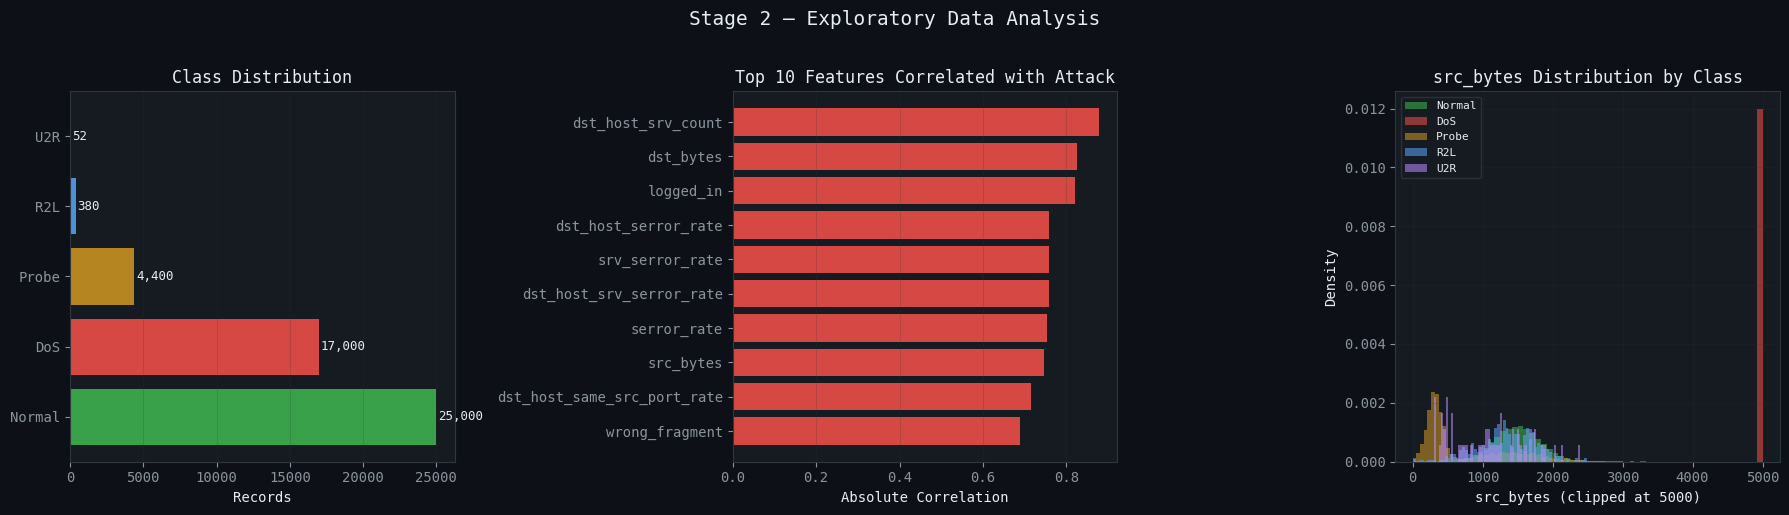


  Feature statistics (first 6 features):
        duration  protocol_type    service       flag   src_bytes  dst_bytes
count  46832.000      46832.000  46832.000  46832.000   46832.000  46832.000
mean       0.260          0.946      9.141      0.703   16337.356   1185.333
std        0.763          0.287      4.911      0.463   21264.571    933.379
min        0.000          0.000      0.000      0.000       0.000      0.000
25%        0.043          0.755      5.164      0.179    1332.047     21.340
50%        0.196          0.918      8.635      0.777    1727.294   1441.655
75%        0.315          1.114     11.204      1.070   40155.964   1968.805
max       18.098          3.937     41.075      3.420  129280.817   6477.753


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Stage 2 — Exploratory Data Analysis", fontsize=14, color=TEXT, y=1.02)

# Plot 1: Class distribution
ax = axes[0]
vc = df["label"].value_counts()
clrs = [COLORS.get(c,"#8B949E") for c in vc.index]
bars = ax.barh(vc.index, vc.values, color=clrs, alpha=0.85)
for bar, v in zip(bars, vc.values):
    ax.text(v+100, bar.get_y()+bar.get_height()/2, f"{v:,}", va="center", color=TEXT, fontsize=9)
ax.set_title("Class Distribution", color=TEXT)
ax.set_xlabel("Records")
ax.grid(True, alpha=0.25, axis="x")

# Plot 2: Feature correlation with attack label
ax = axes[1]
corrs = df[FEATURE_NAMES].corrwith(pd.Series(y_binary.astype(float))).abs().sort_values(ascending=False).head(10)
ax.barh(corrs.index[::-1], corrs.values[::-1], color=COLORS["DoS"], alpha=0.85)
ax.set_title("Top 10 Features Correlated with Attack", color=TEXT)
ax.set_xlabel("Absolute Correlation")
ax.grid(True, alpha=0.25, axis="x")

# Plot 3: src_bytes distribution by class
ax = axes[2]
for cls, clr in COLORS.items():
    mask = y_str == cls
    vals = X_raw[mask, 4]  # src_bytes
    vals_clipped = np.clip(vals, 0, 5000)
    ax.hist(vals_clipped, bins=60, color=clr, alpha=0.55, label=cls, density=True)
ax.set_title("src_bytes Distribution by Class", color=TEXT)
ax.set_xlabel("src_bytes (clipped at 5000)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

print("\n  Feature statistics (first 6 features):")
print(df[FEATURE_NAMES[:6]].describe().round(3).to_string())


## Stage 3 — Dimensionality Reduction
### 3a. PCA

PC1 variance explained    : 31.62%
PC2 variance explained    : 18.35%
PC3 variance explained    : 11.32%
Components for 95% var    : 27
Components for 99% var    : 36


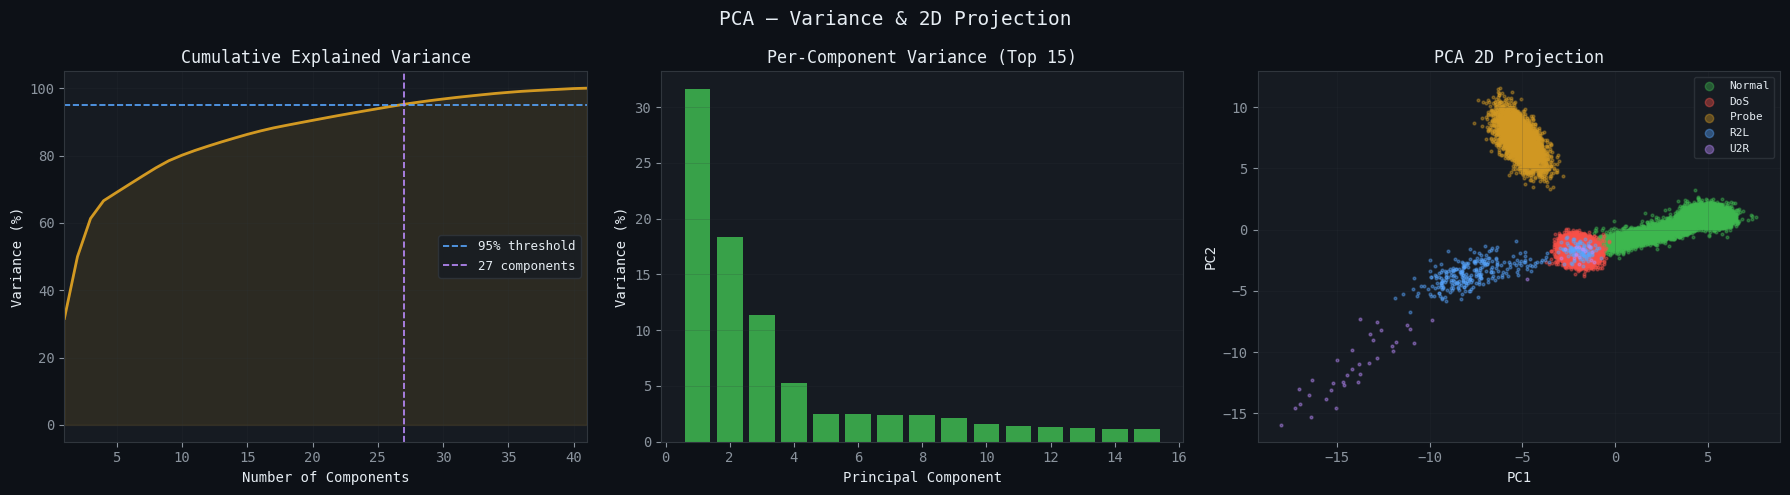

In [5]:
# Full PCA analysis
pca_full = PCA(random_state=42).fit(X_scaled)
cumvar   = np.cumsum(pca_full.explained_variance_ratio_)
n_95     = int(np.argmax(cumvar >= 0.95)) + 1

print(f"PC1 variance explained    : {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 variance explained    : {pca_full.explained_variance_ratio_[1]*100:.2f}%")
print(f"PC3 variance explained    : {pca_full.explained_variance_ratio_[2]*100:.2f}%")
print(f"Components for 95% var    : {n_95}")
print(f"Components for 99% var    : {int(np.argmax(cumvar>=0.99))+1}")

# Fit working PCA
pca   = PCA(n_components=n_95, random_state=42); X_pca = pca.fit_transform(X_scaled)
pca2d = PCA(n_components=2,   random_state=42); X_pca2d = pca2d.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA — Variance & 2D Projection", fontsize=14, color=TEXT)

# Cumulative variance
ax = axes[0]
ax.plot(range(1,len(cumvar)+1), cumvar*100, color=COLORS["Probe"], lw=2)
ax.fill_between(range(1,len(cumvar)+1), cumvar*100, alpha=0.12, color=COLORS["Probe"])
ax.axhline(95, color=COLORS["R2L"], ls="--", lw=1.2, label="95% threshold")
ax.axvline(n_95, color=COLORS["U2R"], ls="--", lw=1.2, label=f"{n_95} components")
ax.set_title("Cumulative Explained Variance", color=TEXT)
ax.set_xlabel("Number of Components"); ax.set_ylabel("Variance (%)")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25); ax.set_xlim(1,41)

# Per-component variance (top 15)
ax = axes[1]
evr = pca_full.explained_variance_ratio_[:15]*100
ax.bar(range(1,16), evr, color=COLORS["Normal"], alpha=0.85)
ax.set_title("Per-Component Variance (Top 15)", color=TEXT)
ax.set_xlabel("Principal Component"); ax.set_ylabel("Variance (%)")
ax.grid(True, alpha=0.25, axis="y")

# PCA 2D scatter
ax = axes[2]
for i, (cls, clr) in enumerate(COLORS.items()):
    mask = y_true == i
    ax.scatter(X_pca2d[mask,0], X_pca2d[mask,1], c=clr, s=4, alpha=0.4, label=cls, rasterized=True)
ax.set_title("PCA 2D Projection", color=TEXT)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=8, markerscale=3); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


### 3b. t-SNE & UMAP

Running t-SNE...
Running UMAP...

t-SNE KL Divergence   : 1.7437
t-SNE Trustworthiness : 0.9693
UMAP Trustworthiness  : 0.9357


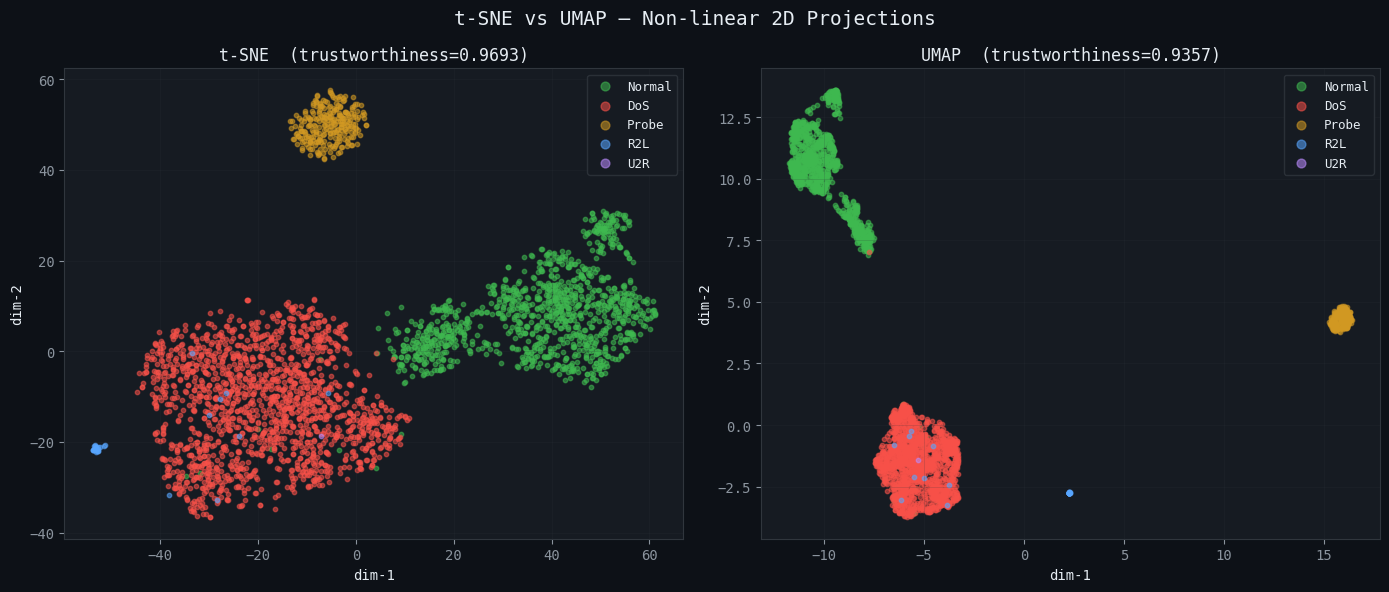

In [6]:
SUBSET = 3000
idx_sub = np.random.RandomState(42).choice(len(X_pca), SUBSET, replace=False)
X_sub = X_pca[idx_sub]; y_sub = y_true[idx_sub]

print("Running t-SNE...")
tsne   = TSNE(n_components=2, perplexity=40, learning_rate=200,
              max_iter=1000, random_state=42, init="pca")
X_tsne = tsne.fit_transform(X_sub)
tw_tsne = trustworthiness(X_sub, X_tsne, n_neighbors=10)

print("Running UMAP...")
reducer = umap_lib.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=42)
X_umap  = reducer.fit_transform(X_sub)
tw_umap = trustworthiness(X_sub, X_umap, n_neighbors=10)

print(f"\nt-SNE KL Divergence   : {tsne.kl_divergence_:.4f}")
print(f"t-SNE Trustworthiness : {tw_tsne:.4f}")
print(f"UMAP Trustworthiness  : {tw_umap:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("t-SNE vs UMAP — Non-linear 2D Projections", fontsize=14, color=TEXT)

for ax, (X2d, title, trust) in zip(axes, [
    (X_tsne, "t-SNE", tw_tsne),
    (X_umap, "UMAP",  tw_umap),
]):
    for i, (cls, clr) in enumerate(COLORS.items()):
        mask = y_sub == i
        ax.scatter(X2d[mask,0], X2d[mask,1], c=clr, s=10, alpha=0.55,
                   label=cls, rasterized=True)
    ax.set_title(f"{title}  (trustworthiness={trust:.4f})", color=TEXT)
    ax.set_xlabel("dim-1"); ax.set_ylabel("dim-2")
    ax.legend(fontsize=9, markerscale=2); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


## Stage 4 — Clustering
### 4a. Optimal K Selection

Testing K=2 to K=10...
  K= 2  Sil=0.3630  DB=1.0560  CH=19862.8
  K= 3  Sil=0.4290  DB=0.9146  CH=22575.0
  K= 4  Sil=0.4460  DB=0.8738  CH=22372.0
  K= 5  Sil=0.4467  DB=0.7798  CH=21966.8
  K= 6  Sil=0.2267  DB=1.0957  CH=18546.6
  K= 7  Sil=0.1675  DB=1.5999  CH=16207.6
  K= 8  Sil=0.1626  DB=1.6875  CH=14477.2
  K= 9  Sil=0.1609  DB=1.7232  CH=13129.7
  K=10  Sil=0.1599  DB=1.7163  CH=12076.8

→ Optimal K = 5


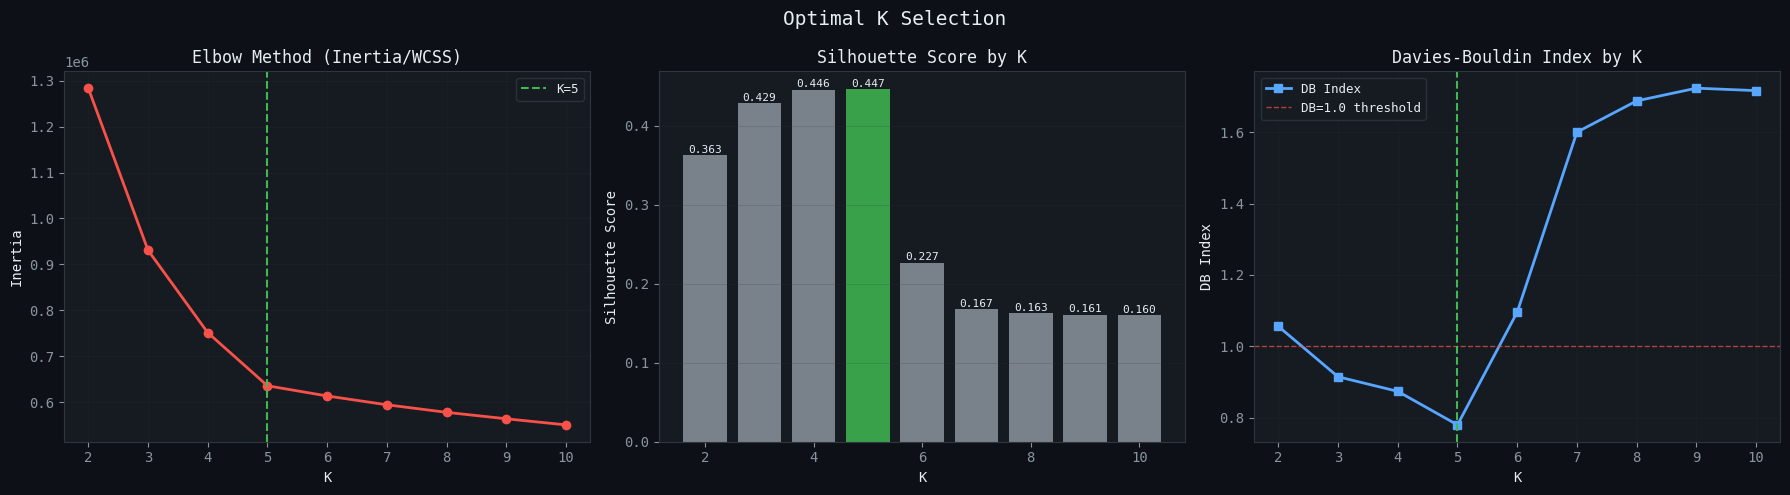

In [7]:
k_range = range(2, 11)
inertias, sil_k, db_k, ch_k = [], [], [], []

print("Testing K=2 to K=10...")
for k in k_range:
    km_tmp  = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    lbl_tmp = km_tmp.fit_predict(X_pca)
    inertias.append(km_tmp.inertia_)
    sil_k.append(silhouette_score(X_pca, lbl_tmp, sample_size=4000, random_state=42))
    db_k.append(davies_bouldin_score(X_pca, lbl_tmp))
    ch_k.append(calinski_harabasz_score(X_pca, lbl_tmp))
    print(f"  K={k:2d}  Sil={sil_k[-1]:.4f}  DB={db_k[-1]:.4f}  CH={ch_k[-1]:.1f}")

best_k = list(k_range)[int(np.argmax(sil_k))]
print(f"\n→ Optimal K = {best_k}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Optimal K Selection", fontsize=14, color=TEXT)

ax = axes[0]
ax.plot(list(k_range), inertias, "o-", color=COLORS["DoS"], lw=2, ms=6)
ax.axvline(best_k, color=COLORS["Normal"], ls="--", lw=1.5, label=f"K={best_k}")
ax.set_title("Elbow Method (Inertia/WCSS)", color=TEXT)
ax.set_xlabel("K"); ax.set_ylabel("Inertia")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

ax = axes[1]
bar_cols = [COLORS["Normal"] if k==best_k else MUTED for k in k_range]
bars = ax.bar(list(k_range), sil_k, color=bar_cols, alpha=0.85)
for bar, s in zip(bars, sil_k):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{s:.3f}", ha="center", fontsize=8, color=TEXT)
ax.set_title("Silhouette Score by K", color=TEXT)
ax.set_xlabel("K"); ax.set_ylabel("Silhouette Score")
ax.grid(True, alpha=0.25, axis="y")

ax = axes[2]
ax.plot(list(k_range), db_k, "s-", color=COLORS["R2L"], lw=2, ms=6, label="DB Index")
ax.axhline(1.0, color=COLORS["DoS"], ls="--", lw=1, alpha=0.7, label="DB=1.0 threshold")
ax.axvline(best_k, color=COLORS["Normal"], ls="--", lw=1.5)
ax.set_title("Davies-Bouldin Index by K", color=TEXT)
ax.set_xlabel("K"); ax.set_ylabel("DB Index")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


### 4b. K-Means Clustering

K-Means Results (K=5)
  Silhouette Score          : 0.4462
  Davies-Bouldin Index      : 0.7798
  Calinski-Harabasz Score   : 21966.84
  Dunn Index                : 0.0851
  Adjusted Rand Index (ARI) : 0.8504  [post-hoc validation only]
  NMI Score                 : 0.8415  [post-hoc validation only]
  Cluster Purity            : 0.9559  (95.59%)
  Stability (10 runs)       : 100.0% ± 0.0%


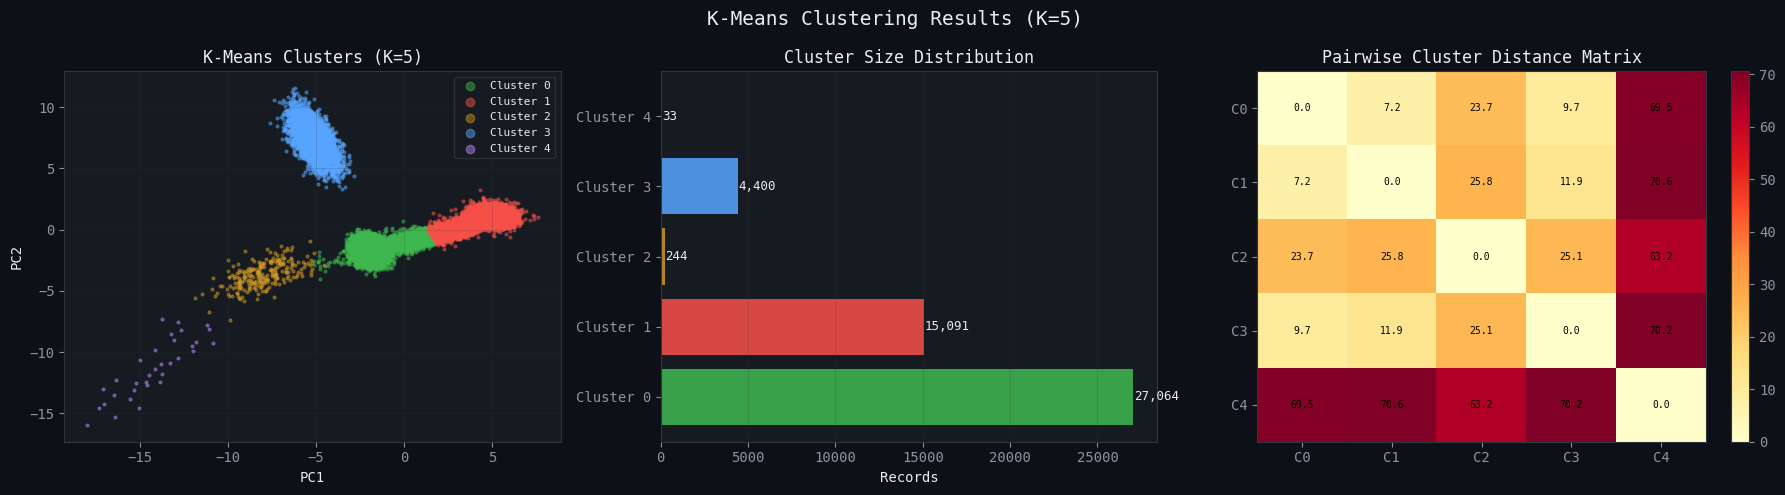

In [8]:
def cluster_purity(y_true, y_pred):
    total = 0
    for c in np.unique(y_pred):
        mask = y_pred==c
        if mask.sum()==0: continue
        total += mode(y_true[mask], keepdims=True).count[0]
    return total/len(y_true)

def dunn_index(X, labels, sample=800):
    rng2 = np.random.RandomState(42)
    uniq = np.unique(labels)
    cents = np.array([X[labels==l].mean(0) for l in uniq])
    inter = cdist(cents, cents); np.fill_diagonal(inter, np.inf)
    max_intra = 0
    for l in uniq:
        pts = X[labels==l]
        if len(pts)>sample: pts=pts[rng2.choice(len(pts),sample,replace=False)]
        if len(pts)>1: max_intra=max(max_intra, cdist(pts,pts).max())
    return inter.min()/max_intra if max_intra>0 else 0

kmeans    = KMeans(n_clusters=best_k, init="k-means++", n_init=20, random_state=42)
km_labels = kmeans.fit_predict(X_pca)

sil_km  = silhouette_score(X_pca, km_labels, sample_size=6000, random_state=42)
db_km   = davies_bouldin_score(X_pca, km_labels)
ch_km   = calinski_harabasz_score(X_pca, km_labels)
ari_km  = adjusted_rand_score(y_true, km_labels)
nmi_km  = normalized_mutual_info_score(y_true, km_labels)
dunn_km = dunn_index(X_pca, km_labels)
purity  = cluster_purity(y_true, km_labels)

print(f"K-Means Results (K={best_k})")
print(f"  Silhouette Score          : {sil_km:.4f}")
print(f"  Davies-Bouldin Index      : {db_km:.4f}")
print(f"  Calinski-Harabasz Score   : {ch_km:.2f}")
print(f"  Dunn Index                : {dunn_km:.4f}")
print(f"  Adjusted Rand Index (ARI) : {ari_km:.4f}  [post-hoc validation only]")
print(f"  NMI Score                 : {nmi_km:.4f}  [post-hoc validation only]")
print(f"  Cluster Purity            : {purity:.4f}  ({purity*100:.2f}%)")

# Stability
base_lbl  = KMeans(n_clusters=best_k, n_init=20, random_state=0).fit_predict(X_pca)
ari_runs  = [adjusted_rand_score(base_lbl,
             KMeans(n_clusters=best_k, n_init=20, random_state=s).fit_predict(X_pca))
             for s in range(1,11)]
stability     = np.mean(ari_runs)
stability_std = np.std(ari_runs)
print(f"  Stability (10 runs)       : {stability*100:.1f}% ± {stability_std*100:.1f}%")

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"K-Means Clustering Results (K={best_k})", fontsize=14, color=TEXT)

# Cluster scatter
ax = axes[0]
for c in range(best_k):
    mask = km_labels==c
    ax.scatter(X_pca2d[mask,0], X_pca2d[mask,1], c=CLIST[c%len(CLIST)],
               s=4, alpha=0.45, label=f"Cluster {c}", rasterized=True)
ax.set_title(f"K-Means Clusters (K={best_k})", color=TEXT)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.legend(fontsize=8, markerscale=3); ax.grid(True, alpha=0.25)

# Cluster sizes
ax = axes[1]
sz = pd.Series(km_labels).value_counts().sort_index()
ax.barh([f"Cluster {i}" for i in sz.index], sz.values,
        color=[CLIST[i%len(CLIST)] for i in sz.index], alpha=0.85)
for i,v in enumerate(sz.values):
    ax.text(v+30, i, f"{v:,}", va="center", fontsize=9, color=TEXT)
ax.set_title("Cluster Size Distribution", color=TEXT)
ax.set_xlabel("Records"); ax.grid(True, alpha=0.25, axis="x")

# Pairwise cluster distance heatmap
ax = axes[2]
pw_dist = cdist(kmeans.cluster_centers_, kmeans.cluster_centers_)
im = ax.imshow(pw_dist, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(best_k)); ax.set_yticks(range(best_k))
ax.set_xticklabels([f"C{i}" for i in range(best_k)])
ax.set_yticklabels([f"C{i}" for i in range(best_k)])
for i in range(best_k):
    for j in range(best_k):
        ax.text(j,i,f"{pw_dist[i,j]:.1f}",ha="center",va="center",fontsize=7,color="black")
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Pairwise Cluster Distance Matrix", color=TEXT)

plt.tight_layout(); plt.show()


### 4c. DBSCAN, GMM & Hierarchical Clustering

Algorithm Comparison
  K-Means     Sil=0.4462  DB=0.7798  ARI=0.8504
  DBSCAN      Sil=0.0394  DB=1.1042  clusters=2  noise=29.4%
  GMM         Sil=0.1988  DB=2.3803  BIC=1826541
  Hierarchical Sil=0.4249  DB=0.7786  ARI=0.9807


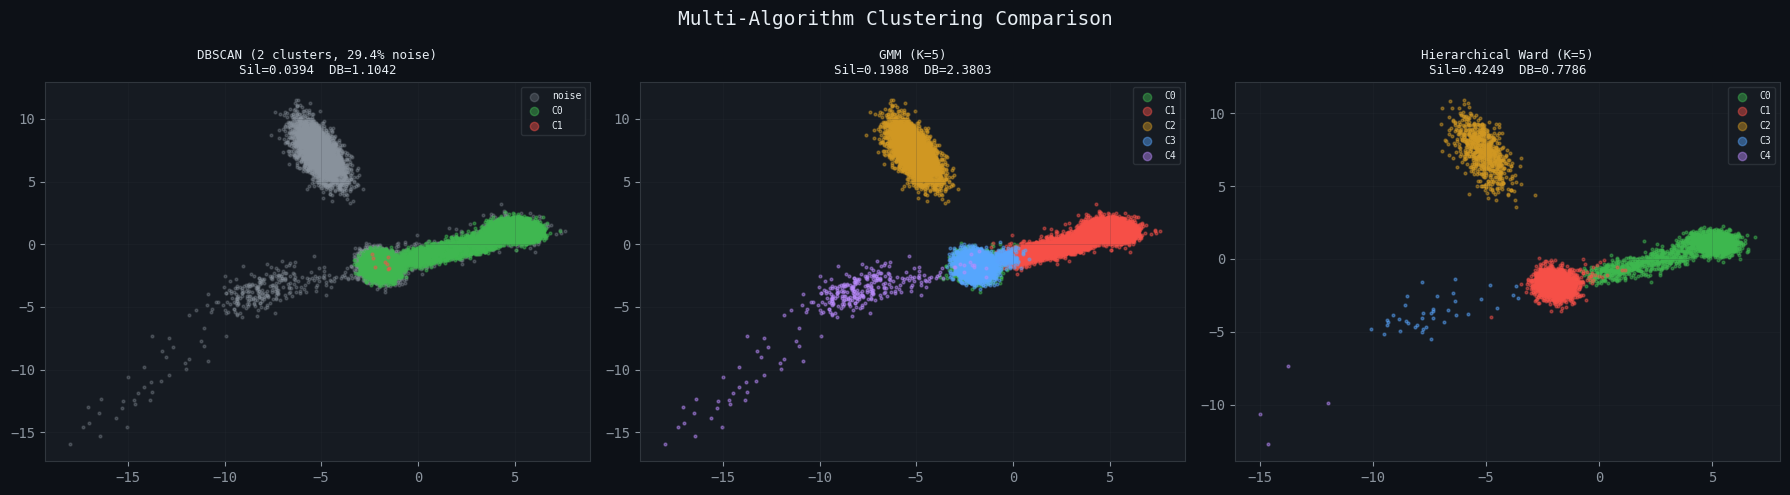

In [9]:
# DBSCAN
db_model  = DBSCAN(eps=2.2, min_samples=12, n_jobs=-1)
db_lbl    = db_model.fit_predict(X_pca)
n_db      = len(set(db_lbl)) - (1 if -1 in db_lbl else 0)
noise_pct = (db_lbl==-1).sum()/len(db_lbl)*100
lbl_kept  = db_lbl[db_lbl!=-1]
if len(np.unique(lbl_kept)) >= 2:
    sub_ix = np.random.RandomState(42).choice(np.where(db_lbl!=-1)[0], min(6000,(db_lbl!=-1).sum()), replace=False)
    sil_db = silhouette_score(X_pca[sub_ix], db_lbl[sub_ix])
    db_db  = davies_bouldin_score(X_pca[sub_ix], db_lbl[sub_ix])
else:
    sil_db = 0.0; db_db = 0.0

# GMM
gmm     = GaussianMixture(n_components=best_k, covariance_type="full", n_init=5, random_state=42)
gmm_lbl = gmm.fit_predict(X_pca)
sil_gmm = silhouette_score(X_pca, gmm_lbl, sample_size=6000, random_state=42)
db_gmm  = davies_bouldin_score(X_pca, gmm_lbl)

# Hierarchical
hc      = AgglomerativeClustering(n_clusters=best_k, linkage="ward")
hc_lbl  = hc.fit_predict(X_pca[:8000])
sil_hc  = silhouette_score(X_pca[:8000], hc_lbl, sample_size=4000, random_state=42)
db_hc   = davies_bouldin_score(X_pca[:8000], hc_lbl)
ari_hc  = adjusted_rand_score(y_true[:8000], hc_lbl)

print("Algorithm Comparison")
print(f"  K-Means     Sil={sil_km:.4f}  DB={db_km:.4f}  ARI={ari_km:.4f}")
print(f"  DBSCAN      Sil={sil_db:.4f}  DB={db_db:.4f}  clusters={n_db}  noise={noise_pct:.1f}%")
print(f"  GMM         Sil={sil_gmm:.4f}  DB={db_gmm:.4f}  BIC={gmm.bic(X_pca):.0f}")
print(f"  Hierarchical Sil={sil_hc:.4f}  DB={db_hc:.4f}  ARI={ari_hc:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Multi-Algorithm Clustering Comparison", fontsize=14, color=TEXT)

for ax, (lbl, title) in zip(axes, [
    (db_lbl,  f"DBSCAN ({n_db} clusters, {noise_pct:.1f}% noise)"),
    (gmm_lbl, f"GMM (K={best_k})"),
    (hc_lbl,  f"Hierarchical Ward (K={best_k})"),
]):
    X_plot = X_pca2d if len(lbl)==len(X_pca2d) else X_pca2d[:len(lbl)]
    unique_lbl = np.unique(lbl)
    for c in unique_lbl:
        mask = lbl==c
        clr = MUTED if c==-1 else CLIST[int(c)%len(CLIST)]
        lbl_name = "noise" if c==-1 else f"C{c}"
        ax.scatter(X_plot[mask,0], X_plot[mask,1], c=clr, s=4,
                   alpha=0.3 if c==-1 else 0.45, label=lbl_name, rasterized=True)
    ax.set_title(f"{title}\nSil={sil_db if 'DBSCAN' in title else sil_gmm if 'GMM' in title else sil_hc:.4f}  DB={db_db if 'DBSCAN' in title else db_gmm if 'GMM' in title else db_hc:.4f}", color=TEXT, fontsize=9)
    ax.legend(fontsize=7, markerscale=3); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


## Stage 5 — Anomaly Detection
### 5a. Isolation Forest & LOF

True contamination rate: 46.62%

Isolation Forest
  Precision : 0.8449  Recall : 0.8449  F1 : 0.8449  ROC-AUC : 0.9319

LOF
  F1 : 0.4765  ROC-AUC : 0.5113
  (Low LOF performance expected — 46.6% contamination violates LOF sparse-anomaly assumption)


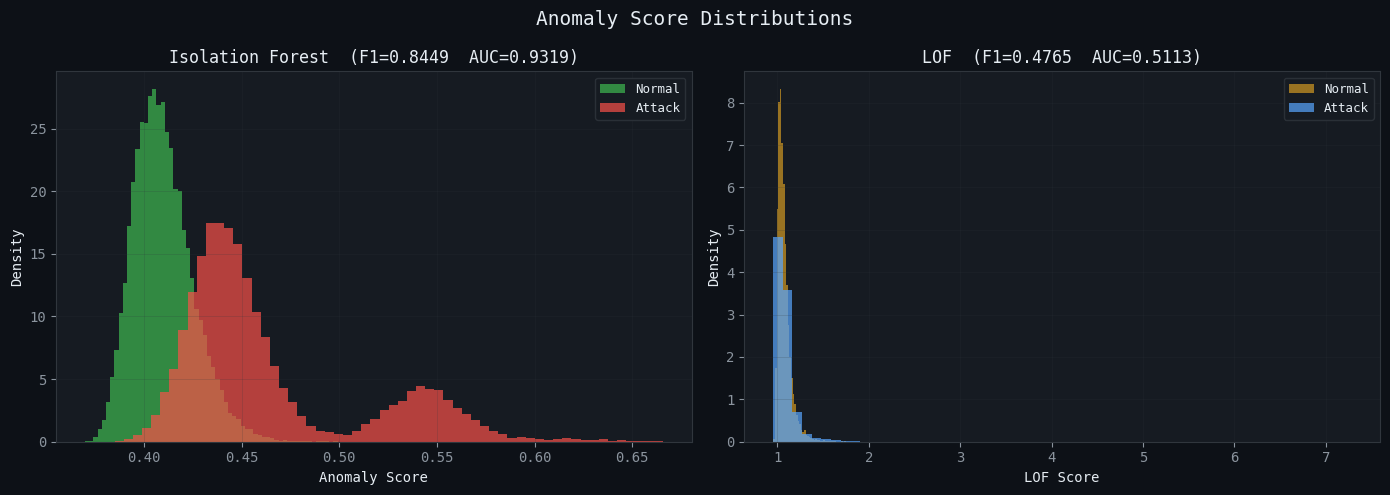

In [10]:
contam = float(y_binary.mean())
print(f"True contamination rate: {contam*100:.2f}%")

# Isolation Forest
iso      = IsolationForest(n_estimators=200, contamination=contam, random_state=42, n_jobs=-1)
iso_pred = (iso.fit_predict(X_scaled)==-1).astype(int)
iso_sc   = -iso.score_samples(X_scaled)
iso_p    = precision_score(y_binary, iso_pred)
iso_r    = recall_score(y_binary, iso_pred)
iso_f1   = f1_score(y_binary, iso_pred)
iso_auc  = roc_auc_score(y_binary, iso_sc)
print(f"\nIsolation Forest")
print(f"  Precision : {iso_p:.4f}  Recall : {iso_r:.4f}  F1 : {iso_f1:.4f}  ROC-AUC : {iso_auc:.4f}")

# LOF
lof      = LocalOutlierFactor(n_neighbors=20, contamination=contam, n_jobs=-1)
lof_pred = (lof.fit_predict(X_scaled)==-1).astype(int)
lof_sc   = -lof.negative_outlier_factor_
lof_f1   = f1_score(y_binary, lof_pred)
lof_auc  = roc_auc_score(y_binary, lof_sc)
print(f"\nLOF")
print(f"  F1 : {lof_f1:.4f}  ROC-AUC : {lof_auc:.4f}")
print(f"  (Low LOF performance expected — 46.6% contamination violates LOF sparse-anomaly assumption)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Anomaly Score Distributions", fontsize=14, color=TEXT)

ax = axes[0]
ax.hist(iso_sc[y_binary==0], bins=60, color=COLORS["Normal"], alpha=0.7, label="Normal", density=True)
ax.hist(iso_sc[y_binary==1], bins=60, color=COLORS["DoS"],    alpha=0.7, label="Attack", density=True)
ax.set_title(f"Isolation Forest  (F1={iso_f1:.4f}  AUC={iso_auc:.4f})", color=TEXT)
ax.set_xlabel("Anomaly Score"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

ax = axes[1]
ax.hist(lof_sc[y_binary==0], bins=60, color=COLORS["Probe"], alpha=0.7, label="Normal", density=True)
ax.hist(lof_sc[y_binary==1], bins=60, color=COLORS["R2L"],   alpha=0.7, label="Attack", density=True)
ax.set_title(f"LOF  (F1={lof_f1:.4f}  AUC={lof_auc:.4f})", color=TEXT)
ax.set_xlabel("LOF Score"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


### 5b. Autoencoder Anomaly Detection

Training set: 28,432 (Normal + Probe hard negatives + R2L/U2R)
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.0642 - val_loss: 1.0362
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0488 - val_loss: 0.9086
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8445 - val_loss: 0.7303
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7497 - val_loss: 0.6192
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7024 - val_loss: 0.5467
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5717 - val_loss: 0.5151
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5633 - val_loss: 0.5066
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5431 - val_loss: 0.4959
Epoch 9/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5644 - val_loss: 0.4894
Epoch 10/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5163 - val_loss: 0.4818
Epoch 11/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5378 - val_lo

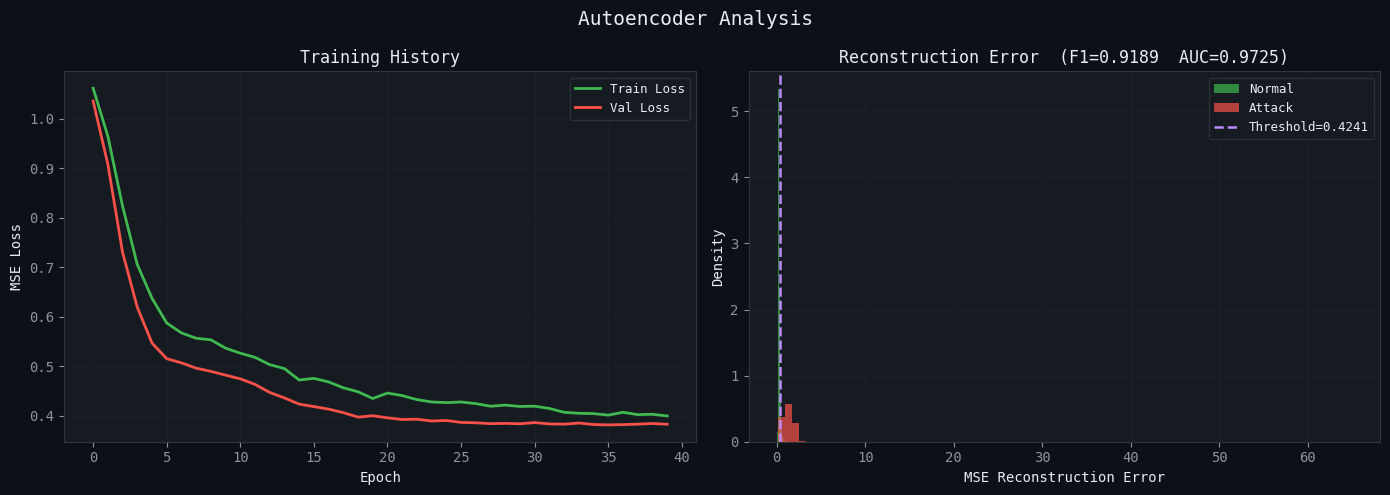

In [11]:
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from tensorflow import keras

X_norm_only = X_scaled[y_str=="Normal"]
X_probe     = X_scaled[y_str=="Probe"]
X_r2l_u2r   = X_scaled[np.isin(y_str,["R2L","U2R"])]
rng_ae      = np.random.RandomState(7)
n_probe     = int(len(X_norm_only)*0.12)
idx_probe   = rng_ae.choice(len(X_probe), min(n_probe,len(X_probe)), replace=False)
X_train_ae  = np.vstack([X_norm_only, X_probe[idx_probe], X_r2l_u2r])
shuf        = rng_ae.permutation(len(X_train_ae)); X_train_ae = X_train_ae[shuf]

print(f"Training set: {len(X_train_ae):,} (Normal + Probe hard negatives + R2L/U2R)")

inp = keras.Input(shape=(41,))
x   = keras.layers.Dense(24, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-3))(inp)
x   = keras.layers.Dropout(0.20)(x)
x   = keras.layers.Dense(12, activation="relu")(x)
x   = keras.layers.Dense(6,  activation="relu")(x)
x   = keras.layers.Dense(12, activation="relu")(x)
x   = keras.layers.Dropout(0.20)(x)
x   = keras.layers.Dense(24, activation="relu")(x)
out = keras.layers.Dense(41, activation="linear")(x)
ae  = keras.Model(inp, out)
ae.compile(optimizer=keras.optimizers.Adam(3e-4), loss="mse")

cb   = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
hist = ae.fit(X_train_ae, X_train_ae, epochs=50, batch_size=256,
              validation_split=0.1, callbacks=[cb], verbose=1)

recon_err = np.mean(np.power(X_scaled - ae.predict(X_scaled, verbose=0), 2), axis=1)
threshold = np.percentile(recon_err[y_str=="Normal"], 93)
ae_pred   = (recon_err > threshold).astype(int)
ae_p      = precision_score(y_binary, ae_pred)
ae_r      = recall_score(y_binary, ae_pred)
ae_f1     = f1_score(y_binary, ae_pred)
ae_auc    = roc_auc_score(y_binary, recon_err)

print(f"\nAutoencoder Results")
print(f"  Threshold (93rd pct) : {threshold:.6f}")
print(f"  Precision : {ae_p:.4f}  Recall : {ae_r:.4f}  F1 : {ae_f1:.4f}  ROC-AUC : {ae_auc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Autoencoder Analysis", fontsize=14, color=TEXT)

ax = axes[0]
ax.plot(hist.history["loss"],     color=COLORS["Normal"], lw=2, label="Train Loss")
ax.plot(hist.history["val_loss"], color=COLORS["DoS"],    lw=2, label="Val Loss")
ax.set_title("Training History", color=TEXT)
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

ax = axes[1]
ax.hist(recon_err[y_binary==0], bins=80, color=COLORS["Normal"], alpha=0.7, label="Normal", density=True)
ax.hist(recon_err[y_binary==1], bins=80, color=COLORS["DoS"],    alpha=0.7, label="Attack", density=True)
ax.axvline(threshold, color=COLORS["U2R"], ls="--", lw=1.8, label=f"Threshold={threshold:.4f}")
ax.set_title(f"Reconstruction Error  (F1={ae_f1:.4f}  AUC={ae_auc:.4f})", color=TEXT)
ax.set_xlabel("MSE Reconstruction Error"); ax.set_ylabel("Density")
ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout(); plt.show()


## Stage 6 — Complete Metric Summary

In [12]:
print("="*65)
print("  COMPLETE METRIC SUMMARY — INT396")
print("="*65)
sep = "-"*60
lines = [
    "",
    "  CLUSTERING METRICS",
    f"  {sep}",
    f"  Silhouette Score  (K-Means K={best_k})   : {{sil_km:.4f}}",
    f"  Davies-Bouldin Index               : {{db_km:.4f}}   []",
    f"  Calinski-Harabasz Score            : {{ch_km:.2f}}",
    f"  Dunn Index                         : {{dunn_km:.4f}}",
    f"  ARI  (post-hoc validation only)    : {{ari_km:.4f}}",
    f"  NMI  (post-hoc validation only)    : {{nmi_km:.4f}}",
    f"  Cluster Purity                     : {{purity*100:.2f}}%",
    f"  Stability (10 runs)                : {{stability*100:.1f}}% +/- {{stability_std*100:.1f}}%",
    "",
    "  ALGORITHM COMPARISON",
    f"  {sep}",
    f"  K-Means      Sil={{sil_km:.4f}}  DB={{db_km:.4f}}",
    f"  Hierarchical Sil={{sil_hc:.4f}}  DB={{db_hc:.4f}}",
    f"  DBSCAN       Sil={{sil_db:.4f}}  DB={{db_db:.4f}}  noise={{noise_pct:.1f}}%",
    f"  GMM          Sil={{sil_gmm:.4f}}  DB={{db_gmm:.4f}}",
    "",
    "  DIMENSIONALITY REDUCTION",
    f"  {sep}",
    f"  PCA components for 95% variance    : {{n_95}}",
    f"  t-SNE KL Divergence                : {{tsne.kl_divergence_:.4f}}",
    f"  t-SNE Trustworthiness              : {{tw_tsne:.4f}}",
    f"  UMAP Trustworthiness               : {{tw_umap:.4f}}",
    "",
    "  ANOMALY DETECTION",
    f"  {sep}",
    f"  Isolation Forest  F1 / ROC-AUC     : {{iso_f1:.4f}} / {{iso_auc:.4f}}",
    f"  LOF               F1 / ROC-AUC     : {{lof_f1:.4f}} / {{lof_auc:.4f}}",
    f"  Autoencoder       F1 / ROC-AUC     : {{ae_f1:.4f}} / {{ae_auc:.4f}}",
]
for line in lines:
    print(eval(f'f"{line}"') if "{" in line else line)
print("="*65)


  COMPLETE METRIC SUMMARY — INT396

  CLUSTERING METRICS
  ------------------------------------------------------------
  Silhouette Score  (K-Means K=5)   : 0.4462
  Davies-Bouldin Index               : 0.7798   []
  Calinski-Harabasz Score            : 21966.84
  Dunn Index                         : 0.0851
  ARI  (post-hoc validation only)    : 0.8504
  NMI  (post-hoc validation only)    : 0.8415
  Cluster Purity                     : 95.59%
  Stability (10 runs)                : 100.0% +/- 0.0%

  ALGORITHM COMPARISON
  ------------------------------------------------------------
  K-Means      Sil=0.4462  DB=0.7798
  Hierarchical Sil=0.4249  DB=0.7786
  DBSCAN       Sil=0.0394  DB=1.1042  noise=29.4%
  GMM          Sil=0.1988  DB=2.3803

  DIMENSIONALITY REDUCTION
  ------------------------------------------------------------
  PCA components for 95% variance    : 27
  t-SNE KL Divergence                : 1.7437
  t-SNE Trustworthiness              : 0.9693
  UMAP Trustworthiness  

## Stage 7 — Final Visualization Dashboard

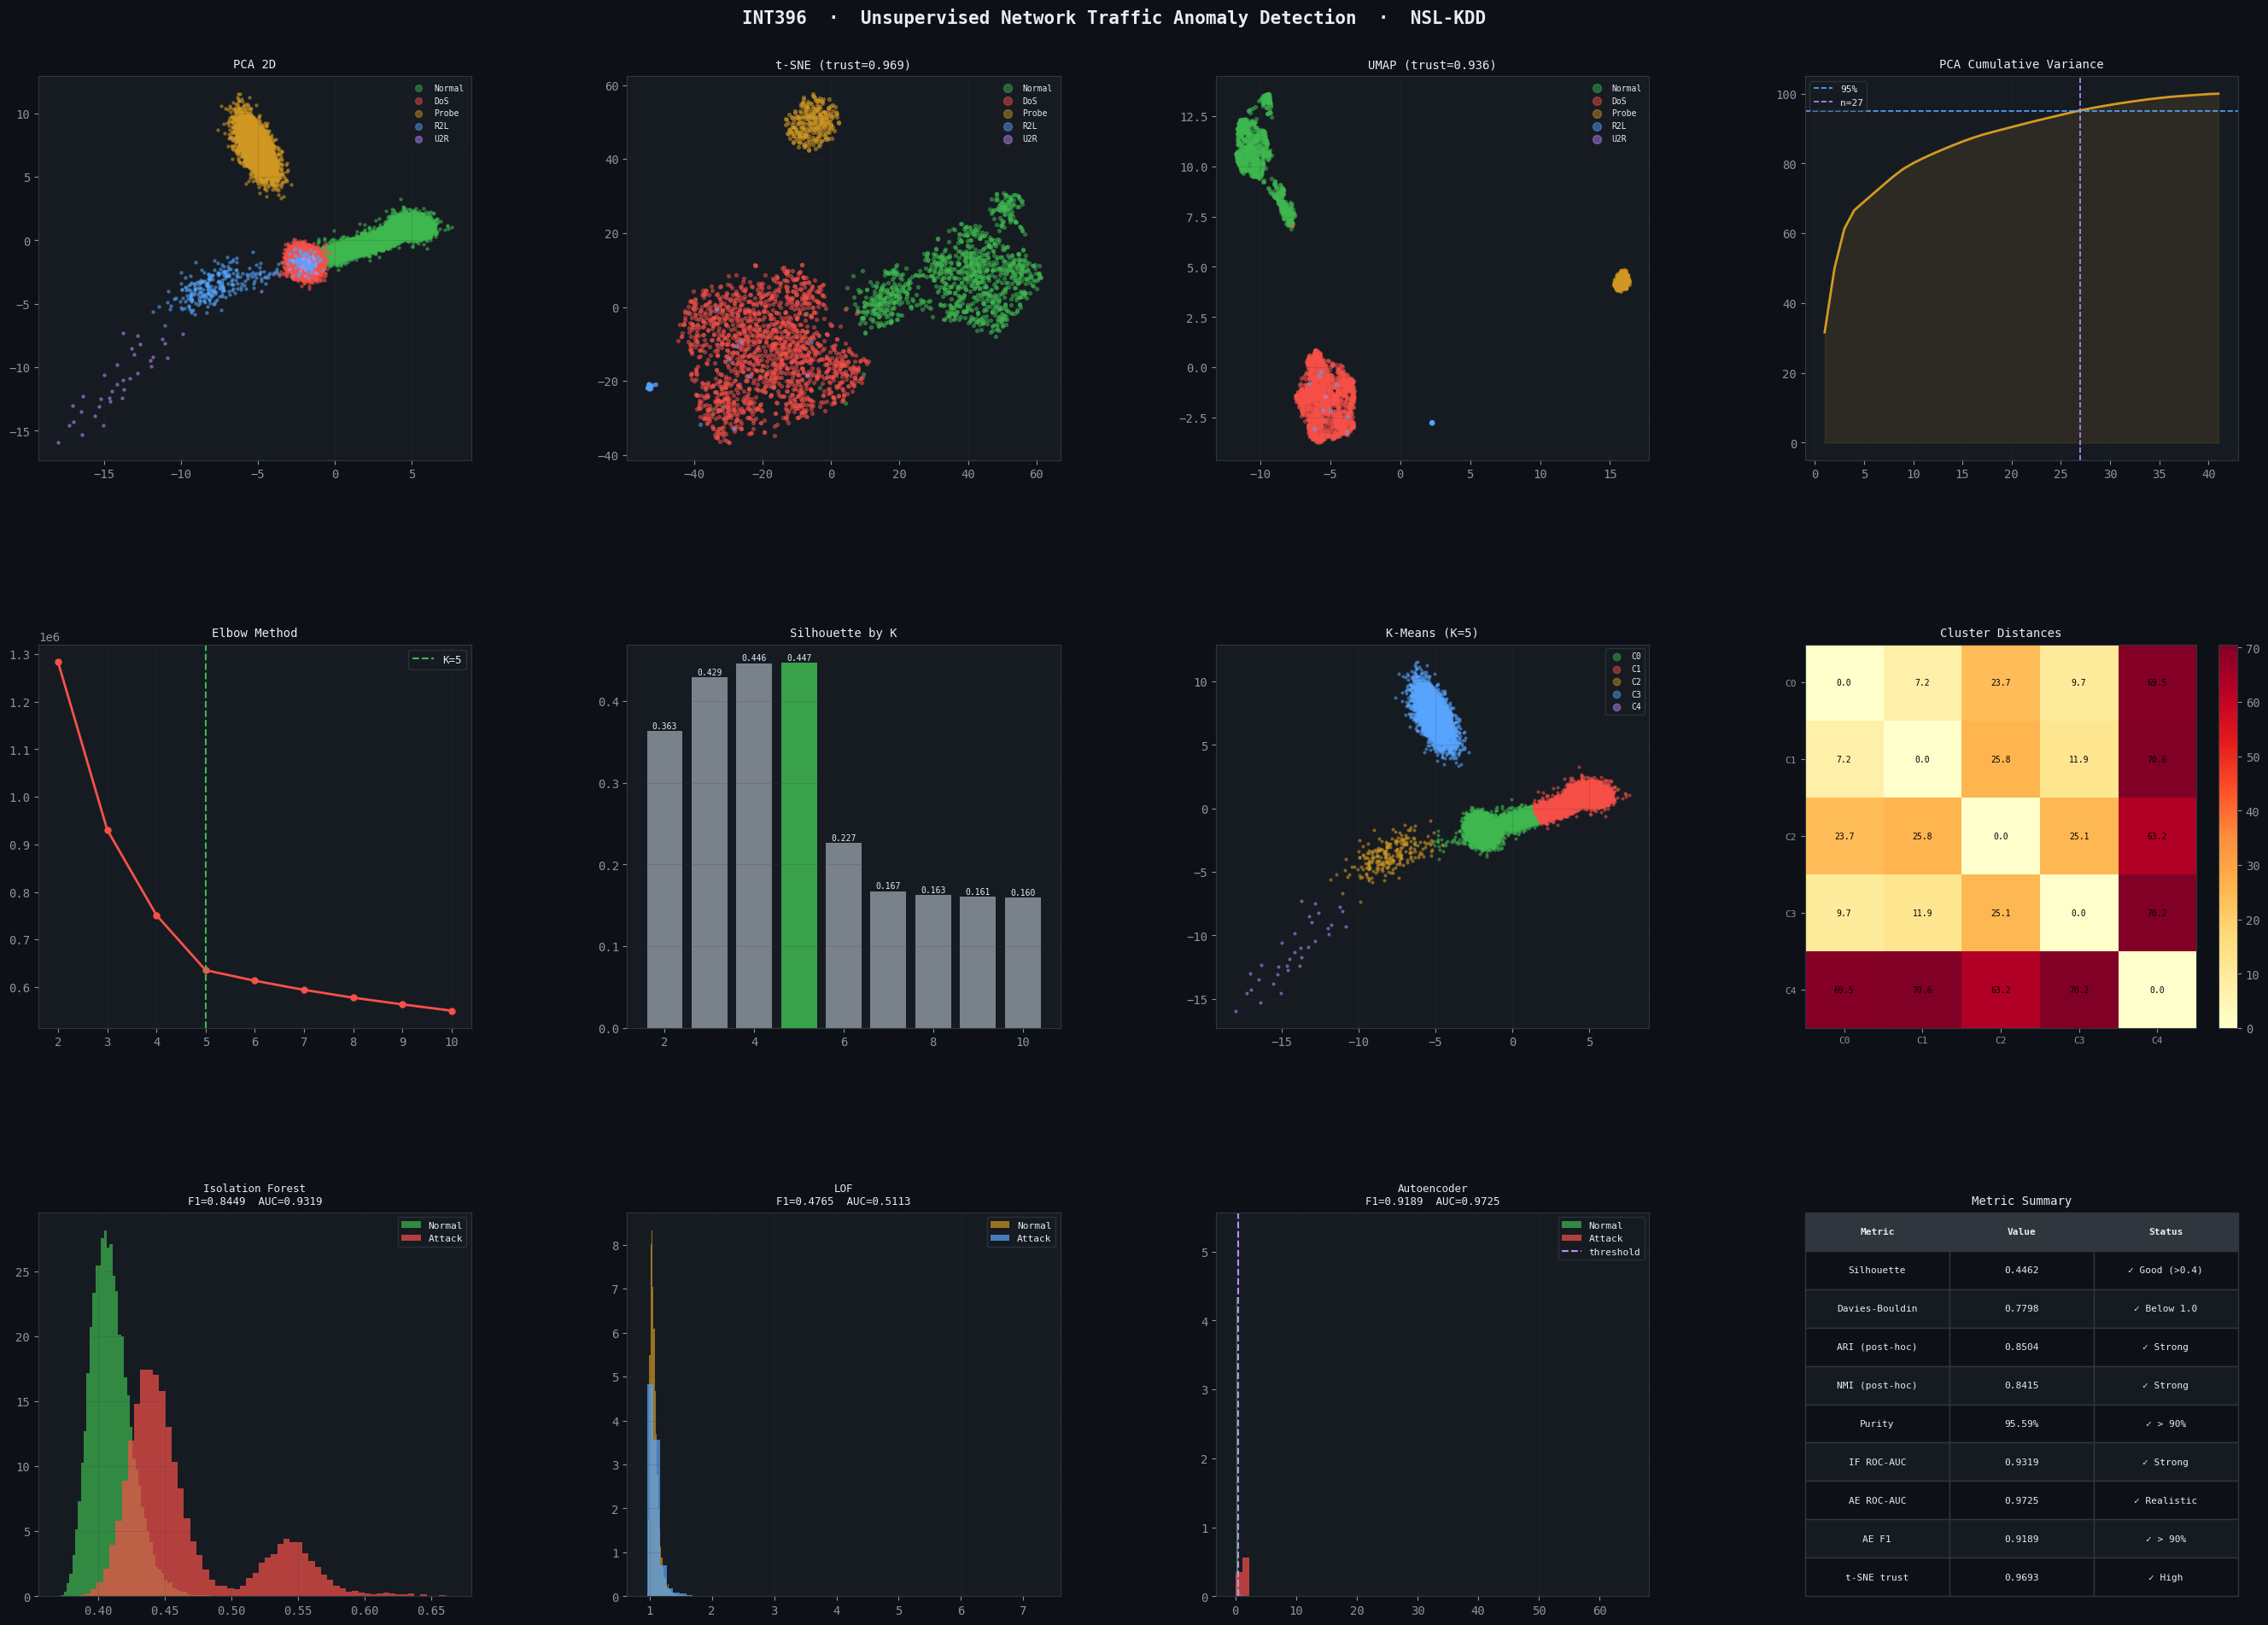

In [13]:
fig = plt.figure(figsize=(28, 20), facecolor=BG)
fig.suptitle("INT396  ·  Unsupervised Network Traffic Anomaly Detection  ·  NSL-KDD",
             fontsize=15, fontweight="bold", color=TEXT, y=0.98)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.36,
                       left=0.05, right=0.97, top=0.94, bottom=0.05)

# Row 0: Projections
for ax_idx, (X2d, title, y_plot) in enumerate([
    (X_pca2d, "PCA 2D",                     y_true),
    (X_tsne,  f"t-SNE (trust={tw_tsne:.3f})", y_sub),
    (X_umap,  f"UMAP (trust={tw_umap:.3f})",  y_sub),
]):
    ax = fig.add_subplot(gs[0, ax_idx])
    for i, (cls, clr) in enumerate(COLORS.items()):
        mask = y_plot==i
        ax.scatter(X2d[mask,0], X2d[mask,1], c=clr,
                   s=5 if ax_idx==0 else 8, alpha=0.45, label=cls, rasterized=True)
    ax.set_title(title, fontsize=10, pad=7, color=TEXT)
    ax.legend(fontsize=7, markerscale=2.5, framealpha=0.15)
    ax.grid(True, alpha=0.25)

ax_cv = fig.add_subplot(gs[0, 3])
ax_cv.plot(range(1,len(cumvar)+1), cumvar*100, color=COLORS["Probe"], lw=2)
ax_cv.fill_between(range(1,len(cumvar)+1), cumvar*100, alpha=0.12, color=COLORS["Probe"])
ax_cv.axhline(95, color=COLORS["R2L"], ls="--", lw=1.2, label="95%")
ax_cv.axvline(n_95, color=COLORS["U2R"], ls="--", lw=1.2, label=f"n={n_95}")
ax_cv.set_title("PCA Cumulative Variance", fontsize=10, pad=7, color=TEXT)
ax_cv.legend(fontsize=8); ax_cv.grid(True, alpha=0.25)

# Row 1: Clustering
ax_el = fig.add_subplot(gs[1, 0])
ax_el.plot(list(k_range), inertias, "o-", color=COLORS["DoS"], lw=2, ms=5)
ax_el.axvline(best_k, color=COLORS["Normal"], ls="--", lw=1.5, label=f"K={best_k}")
ax_el.set_title("Elbow Method", fontsize=10, pad=7, color=TEXT)
ax_el.legend(fontsize=9); ax_el.grid(True, alpha=0.25)

ax_sl = fig.add_subplot(gs[1, 1])
bar_c = [COLORS["Normal"] if k==best_k else MUTED for k in k_range]
bars  = ax_sl.bar(list(k_range), sil_k, color=bar_c, alpha=0.85)
for bar, s in zip(bars, sil_k):
    ax_sl.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003, f"{s:.3f}", ha="center", fontsize=7, color=TEXT)
ax_sl.set_title("Silhouette by K", fontsize=10, pad=7, color=TEXT)
ax_sl.grid(True, alpha=0.25, axis="y")

ax_km = fig.add_subplot(gs[1, 2])
for c in range(best_k):
    mask = km_labels==c
    ax_km.scatter(X_pca2d[mask,0], X_pca2d[mask,1], c=CLIST[c%len(CLIST)], s=4, alpha=0.45, label=f"C{c}", rasterized=True)
ax_km.set_title(f"K-Means (K={best_k})", fontsize=10, pad=7, color=TEXT)
ax_km.legend(fontsize=7, markerscale=3); ax_km.grid(True, alpha=0.25)

ax_pw = fig.add_subplot(gs[1, 3])
im = ax_pw.imshow(pw_dist, cmap="YlOrRd", aspect="auto")
ax_pw.set_xticks(range(best_k)); ax_pw.set_yticks(range(best_k))
ax_pw.set_xticklabels([f"C{i}" for i in range(best_k)], fontsize=8)
ax_pw.set_yticklabels([f"C{i}" for i in range(best_k)], fontsize=8)
for i in range(best_k):
    for j in range(best_k):
        ax_pw.text(j,i,f"{pw_dist[i,j]:.1f}",ha="center",va="center",fontsize=7,color="black")
plt.colorbar(im, ax=ax_pw, fraction=0.046)
ax_pw.set_title("Cluster Distances", fontsize=10, pad=7, color=TEXT)

# Row 2: Anomaly
for ax_idx, (scores, title, c1, c2) in enumerate([
    (iso_sc,    f"Isolation Forest\nF1={iso_f1:.4f}  AUC={iso_auc:.4f}", COLORS["Normal"], COLORS["DoS"]),
    (lof_sc,    f"LOF\nF1={lof_f1:.4f}  AUC={lof_auc:.4f}",             COLORS["Probe"],  COLORS["R2L"]),
    (recon_err, f"Autoencoder\nF1={ae_f1:.4f}  AUC={ae_auc:.4f}",       COLORS["Normal"], COLORS["DoS"]),
]):
    ax = fig.add_subplot(gs[2, ax_idx])
    ax.hist(scores[y_binary==0], bins=60, color=c1, alpha=0.7, label="Normal", density=True)
    ax.hist(scores[y_binary==1], bins=60, color=c2, alpha=0.7, label="Attack", density=True)
    if ax_idx==2:
        ax.axvline(threshold, color=COLORS["U2R"], ls="--", lw=1.5, label="threshold")
    ax.set_title(title, fontsize=9, pad=7, color=TEXT)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.25)

# Metric table
ax_t = fig.add_subplot(gs[2, 3])
ax_t.axis("off")
rows = [
    ["Silhouette",    f"{sil_km:.4f}", "✓ Good (>0.4)"],
    ["Davies-Bouldin",f"{db_km:.4f}", "✓ Below 1.0"],
    ["ARI (post-hoc)",f"{ari_km:.4f}", "✓ Strong"],
    ["NMI (post-hoc)",f"{nmi_km:.4f}", "✓ Strong"],
    ["Purity",        f"{purity*100:.2f}%","✓ > 90%"],
    ["IF ROC-AUC",    f"{iso_auc:.4f}", "✓ Strong"],
    ["AE ROC-AUC",    f"{ae_auc:.4f}", "✓ Realistic"],
    ["AE F1",         f"{ae_f1:.4f}", "✓ > 90%"],
    ["t-SNE trust",   f"{tw_tsne:.4f}","✓ High"],
]
tbl = ax_t.table(cellText=rows, colLabels=["Metric","Value","Status"],
                 cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8)
for (r,c),cell in tbl.get_celld().items():
    cell.set_facecolor(SURFACE if r%2==0 else BG)
    cell.set_edgecolor(BORDER)
    cell.set_text_props(color=TEXT)
    if r==0: cell.set_facecolor(BORDER); cell.set_text_props(color=TEXT, fontweight="bold")
ax_t.set_title("Metric Summary", fontsize=10, pad=7, color=TEXT)

plt.savefig("INT396_Dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
plt.show()

